In [140]:
library(randomForest)
library(caret) 

In [1]:
set.seed(42) 
cobre_data = readRDS("/nfs/dcmb-lgarmire/yhdu/COBRE Final Documents/Figure 1 Differential analysis/cobre_beta_nocrosshyb.rds")
pd = readRDS("/nfs/dcmb-lgarmire/yhdu/COBRE Final Documents/Figure 1 Differential analysis/cobre_pd.rds")
rownames(pd) = pd$Sample_Name
load('/nfs/dcmb-lgarmire/yhdu/COBRE Final Documents/Figure 1 Differential analysis/cobre_model_markers173_12.rdata')

In [180]:
BLCA = readRDS('tcga_common_diff/BLCA_common_dm.rds')
HNSC = readRDS('tcga_common_diff/HNSC_common_dm.rds')
LUAD = readRDS('tcga_common_diff/LUAD_common_dm.rds')
THCA = readRDS('tcga_common_diff/THCA_common_dm.rds')
BRCA = readRDS('tcga_common_diff/BRCA_common_dm.rds')
KIRC = readRDS('tcga_common_diff/KIRC_common_dm.rds')
LUSC = readRDS('tcga_common_diff/LUSC_common_dm.rds')
UCEC = readRDS('tcga_common_diff/UCEC_common_dm.rds')
COAD = readRDS('tcga_common_diff/COAD_common_dm.rds')
KIRP = readRDS('tcga_common_diff/KIRP_common_dm.rds')
PAAD = readRDS('tcga_common_diff/PAAD_common_dm.rds')
ESCA = readRDS('tcga_common_diff/ESCA_common_dm.rds')
LIHC = readRDS('tcga_common_diff/LIHC_common_dm.rds')
PRAD = readRDS('tcga_common_diff/PRAD_common_dm.rds')

feature_list = list(cobre_model_top5_pathway_173,rownames(BLCA),rownames(HNSC),rownames(LUAD),rownames(THCA),rownames(BRCA),rownames(KIRC),rownames(LUSC),rownames(UCEC),rownames(COAD),rownames(KIRP),rownames(PAAD),rownames(ESCA),rownames(LIHC),rownames(PRAD))
#feature_list = list(rownames(topspearman),rownames(BLCA),rownames(HNSC),rownames(LUAD),rownames(THCA),rownames(BRCA),rownames(KIRC),rownames(LUSC),rownames(UCEC),rownames(COAD),rownames(KIRP),rownames(PAAD),rownames(ESCA),rownames(LIHC),rownames(PRAD))

common_rownames <- Reduce(intersect, feature_list)


In [183]:
write.csv(common_rownames,'61obesitymaers.csv',quote=FALSE)

In [124]:
length(common_rownames)

[1] 61

In [7]:
beta = as.data.frame(t(cobre_data[,pd$Sample_Name]))
beta = beta[,common_rownames]
beta$Group = as.factor(pd$Sample_Group)
dim(beta)

[1] 72 62

In [121]:
train_control <- trainControl(
  method = "cv",       
  number = 5,          
  verboseIter = FALSE,  
  savePredictions = TRUE, 
  classProbs = TRUE    
)
train_index <- createDataPartition(beta$Group, p = 0.8, list = FALSE) 
train_data <- beta[train_index, ]
test_data <- beta[-train_index, ]
training_cols = colnames(beta)

In [127]:
rf_model_cv2 <- train(
  Group ~ .,                # Formula: classify based on all other columns
  data = train_data,        # Use only the training dataset
  method = "rf",            # Random Forest
  trControl = train_control, # 5-fold CV
  ntree = 500,              # Number of trees
  importance = TRUE,        # Enable importance calculation
  tuneGrid = expand.grid(mtry = sqrt(ncol(train_data) - 1))  # Default tuning of mtry
)
# Print model summary
print(rf_model_cv2)

test_predictions <- predict(rf_model_cv2, newdata = test_data)
# Confusion matrix for the test set
test_conf_matrix <- confusionMatrix(test_predictions, test_data$Group)
print(test_conf_matrix)

Random Forest 

59 samples
61 predictors
 2 classes: 'control', 'obese' 

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 48, 48, 47, 47, 46 
Resampling results:

  Accuracy   Kappa    
  0.8465035  0.6889427

Tuning parameter 'mtry' was held constant at a value of 7.81025
Confusion Matrix and Statistics

          Reference
Prediction control obese
   control       6     0
   obese         1     6
                                          
               Accuracy : 0.9231          
                 95% CI : (0.6397, 0.9981)
    No Information Rate : 0.5385          
    P-Value [Acc > NIR] : 0.003884        
                                          
                  Kappa : 0.8471          
                                          
 Mcnemar's Test P-Value : 1.000000        
                                          
            Sensitivity : 0.8571          
            Specificity : 1.0000          
         Pos Pred Value : 1.0000          
      

In [128]:
# Best tuning parameters
cat("Best mtry parameter:", rf_model_cv2$bestTune$mtry, "\n")

# Model accuracy across folds
print(rf_model_cv2$results)

# Final model confusion matrix
conf_matrix <- confusionMatrix(rf_model_cv2$pred$pred, rf_model_cv2$pred$obs)
print(conf_matrix)

# Plot feature importance
#varImpPlot(rf_model_cv$finalModel, main = "Feature Importance")
save(rf_model_cv2,file='rf_model_cv_62.rdata')

Best mtry parameter: 7.81025 
     mtry  Accuracy     Kappa AccuracySD  KappaSD
1 7.81025 0.8465035 0.6889427 0.07620631 0.156933
Confusion Matrix and Statistics

          Reference
Prediction control obese
   control      29     7
   obese         2    21
                                          
               Accuracy : 0.8475          
                 95% CI : (0.7301, 0.9278)
    No Information Rate : 0.5254          
    P-Value [Acc > NIR] : 2.008e-07       
                                          
                  Kappa : 0.6915          
                                          
 Mcnemar's Test P-Value : 0.1824          
                                          
            Sensitivity : 0.9355          
            Specificity : 0.7500          
         Pos Pred Value : 0.8056          
         Neg Pred Value : 0.9130          
             Prevalence : 0.5254          
         Detection Rate : 0.4915          
   Detection Prevalence : 0.6102          
      Balan

In [129]:
library(randomForest)
library(caret) 
library(pROC)

load('/nfs/dcmb-lgarmire/yhdu/COBRE Final Documents/TCGA_clinical/cobre_beta_rf_common.rdata')
load('/nfs/dcmb-lgarmire/yhdu/COBRE Final Documents/TCGA_clinical/rf_model_cv_62.rdata',verbose=TRUE)
tcga_sample_clinical = readRDS('tcga_sample_clinical.rds')

cancers = c("BLCA","HNSC","LUAD","THCA","BRCA","KIRC","LUSC","UCEC","COAD","KIRP","PAAD","ESCA","LIHC","PRAD")
tcga_pred = function(cancer){

	filepath = paste0("/nfs/dcmb-lgarmire/yhdu/COBRE Final Documents/TCGA_clinical/tcga_common_diff/",cancer,"_common_dm.rds")
	TCGA_data = as.data.frame(t(readRDS(filepath)))

	rownames(tcga_sample_clinical) = tcga_sample_clinical$File.Name

	TCGA_data_clinical = tcga_sample_clinical[rownames(TCGA_data),]

	TCGA_data$Group = as.factor(TCGA_data_clinical$Sample.Type)
	levels(TCGA_data$Group) = c('obese','control')
	TCGA_data_clean = TCGA_data[,training_cols]
    print(table(TCGA_data$Group))

	TCGA_predictions <- predict(rf_model_cv2, newdata = TCGA_data_clean)
    TCGA_predictions_prob <- predict(rf_model_cv2, newdata = TCGA_data_clean, type = "prob")
	TCGA_true_labels <- TCGA_data$Group  
    
	conf_matrix_TCGA <- confusionMatrix(TCGA_predictions, TCGA_true_labels)
	accuracy <- conf_matrix_TCGA$overall['Accuracy']
    balanced = conf_matrix_TCGA$byClass['Balanced Accuracy']
    sensitivity <- conf_matrix_TCGA$byClass['Sensitivity']
    specificity <- conf_matrix_TCGA$byClass['Specificity']
    precision <- conf_matrix_TCGA$byClass['Precision']
    recall <- conf_matrix_TCGA$byClass['Recall']
    f1 = conf_matrix_TCGA$byClass['F1']
    roc_curve <- roc(TCGA_true_labels, TCGA_predictions_prob[, 2], levels = rev(levels(TCGA_true_labels)))
    pr_curve <- pr.curve(scores.class0 = TCGA_predictions_prob[, 2], 
                     weights.class0 = 2-as.numeric(TCGA_true_labels), 
                     curve = TRUE)
  
    
	outputpath = paste0("/nfs/dcmb-lgarmire/yhdu/COBRE Final Documents/TCGA_clinical/tcga_common_diff/",cancer,"_obesity_model_pred.rdata")
	save(TCGA_predictions,TCGA_true_labels,conf_matrix_TCGA,accuracy,balanced,sensitivity,specificity,roc_curve,f1,precision,recall,pr_curve,file=outputpath)
}

for (i in cancers){
    tcga_pred(i)
    print(paste0(i,' done!'))
}

Loading objects:
  rf_model_cv2

  obese control 
    418      21 


Warning message in confusionMatrix.default(TCGA_predictions, TCGA_true_labels):
“Levels are not in the same order for reference and data. Refactoring data to match.”
Setting direction: controls > cases



[1] "BLCA done!"

  obese control 
    528      50 


Warning message in confusionMatrix.default(TCGA_predictions, TCGA_true_labels):
“Levels are not in the same order for reference and data. Refactoring data to match.”
Setting direction: controls < cases



[1] "HNSC done!"

  obese control 
    473      32 


...

[1] "ESCA done!"

  obese control 
    377      50 


Warning message in confusionMatrix.default(TCGA_predictions, TCGA_true_labels):
“Levels are not in the same order for reference and data. Refactoring data to match.”
Setting direction: controls < cases



[1] "LIHC done!"

  obese control 
    502      50 


Warning message in confusionMatrix.default(TCGA_predictions, TCGA_true_labels):
“Levels are not in the same order for reference and data. Refactoring data to match.”
Setting direction: controls < cases



[1] "PRAD done!"


In [130]:
load("/nfs/dcmb-lgarmire/yhdu/COBRE Final Documents/TCGA_clinical/tcga_common_diff/BLCA_obesity_model_pred.rdata")
BLCA_conf = conf_matrix_TCGA
BLCA_balanced = balanced
BLCA_sens = sensitivity
BLCA_spec = specificity
BLCA_rov = roc_curve
BLCA_f1 = f1
BLCA_acc = accuracy
BLCA_precision = precision
BLCA_recall = recall
BLCA_pr_curve = pr_curve
load("/nfs/dcmb-lgarmire/yhdu/COBRE Final Documents/TCGA_clinical/tcga_common_diff/HNSC_obesity_model_pred.rdata")
HNSC_conf = conf_matrix_TCGA
HNSC_balanced = balanced
HNSC_sens = sensitivity
HNSC_spec = specificity
HNSC_rov = roc_curve
HNSC_f1 = f1
HNSC_acc = accuracy
HNSC_precision = precision
HNSC_recall = recall
HNSC_pr_curve = pr_curve
load("/nfs/dcmb-lgarmire/yhdu/COBRE Final Documents/TCGA_clinical/tcga_common_diff/LUAD_obesity_model_pred.rdata")
LUAD_conf = conf_matrix_TCGA
LUAD_balanced = balanced
LUAD_sens = sensitivity
LUAD_spec = specificity
LUAD_rov = roc_curve
LUAD_f1 = f1
LUAD_acc = accuracy
LUAD_precision = precision
LUAD_recall = recall
LUAD_pr_curve = pr_curve
load("/nfs/dcmb-lgarmire/yhdu/COBRE Final Documents/TCGA_clinical/tcga_common_diff/THCA_obesity_model_pred.rdata")
THCA_conf = conf_matrix_TCGA
THCA_balanced = balanced
THCA_sens = sensitivity
THCA_spec = specificity
THCA_rov = roc_curve
THCA_f1 = f1
THCA_acc = accuracy
THCA_precision = precision
THCA_recall = recall
THCA_pr_curve = pr_curve
load("/nfs/dcmb-lgarmire/yhdu/COBRE Final Documents/TCGA_clinical/tcga_common_diff/BRCA_obesity_model_pred.rdata")
BRCA_conf = conf_matrix_TCGA
BRCA_balanced = balanced
BRCA_sens = sensitivity
BRCA_spec = specificity
BRCA_rov = roc_curve
BRCA_f1 = f1
BRCA_acc = accuracy
BRCA_precision = precision
BRCA_recall = recall
BRCA_pr_curve = pr_curve
load("/nfs/dcmb-lgarmire/yhdu/COBRE Final Documents/TCGA_clinical/tcga_common_diff/KIRC_obesity_model_pred.rdata")
KIRC_conf = conf_matrix_TCGA
KIRC_balanced = balanced
KIRC_sens = sensitivity
KIRC_spec = specificity
KIRC_rov = roc_curve
KIRC_f1 = f1
KIRC_acc = accuracy
KIRC_precision = precision
KIRC_recall = recall
KIRC_pr_curve = pr_curve
load("/nfs/dcmb-lgarmire/yhdu/COBRE Final Documents/TCGA_clinical/tcga_common_diff/LUSC_obesity_model_pred.rdata")
LUSC_conf = conf_matrix_TCGA
LUSC_balanced = balanced
LUSC_sens = sensitivity
LUSC_spec = specificity
LUSC_rov = roc_curve
LUSC_f1 = f1
LUSC_acc = accuracy
LUSC_precision = precision
LUSC_recall = recall
LUSC_pr_curve = pr_curve
load("/nfs/dcmb-lgarmire/yhdu/COBRE Final Documents/TCGA_clinical/tcga_common_diff/UCEC_obesity_model_pred.rdata")
UCEC_conf = conf_matrix_TCGA
UCEC_balanced = balanced
UCEC_sens = sensitivity
UCEC_spec = specificity
UCEC_rov = roc_curve
UCEC_f1 = f1
UCEC_acc = accuracy
UCEC_precision = precision
UCEC_recall = recall
UCEC_pr_curve = pr_curve
load("/nfs/dcmb-lgarmire/yhdu/COBRE Final Documents/TCGA_clinical/tcga_common_diff/COAD_obesity_model_pred.rdata")
COAD_conf = conf_matrix_TCGA
COAD_balanced = balanced
COAD_sens = sensitivity
COAD_spec = specificity
COAD_rov = roc_curve
COAD_f1 = f1
COAD_acc = accuracy
COAD_precision = precision
COAD_recall = recall
COAD_pr_curve = pr_curve
load("/nfs/dcmb-lgarmire/yhdu/COBRE Final Documents/TCGA_clinical/tcga_common_diff/KIRP_obesity_model_pred.rdata")
KIRP_conf = conf_matrix_TCGA
KIRP_balanced = balanced
KIRP_sens = sensitivity
KIRP_spec = specificity
KIRP_rov = roc_curve
KIRP_f1 = f1
KIRP_acc = accuracy
KIRP_precision = precision
KIRP_recall = recall
KIRP_pr_curve = pr_curve
load("/nfs/dcmb-lgarmire/yhdu/COBRE Final Documents/TCGA_clinical/tcga_common_diff/PAAD_obesity_model_pred.rdata")
PAAD_conf = conf_matrix_TCGA
PAAD_balanced = balanced
PAAD_sens = sensitivity
PAAD_spec = specificity
PAAD_rov = roc_curve
PAAD_f1 = f1
PAAD_acc = accuracy
PAAD_precision = precision
PAAD_recall = recall
PAAD_pr_curve = pr_curve
load("/nfs/dcmb-lgarmire/yhdu/COBRE Final Documents/TCGA_clinical/tcga_common_diff/ESCA_obesity_model_pred.rdata")
ESCA_conf = conf_matrix_TCGA
ESCA_balanced = balanced
ESCA_sens = sensitivity
ESCA_spec = specificity
ESCA_rov = roc_curve
ESCA_f1 = f1
ESCA_acc = accuracy
ESCA_precision = precision
ESCA_recall = recall
ESCA_pr_curve = pr_curve
load("/nfs/dcmb-lgarmire/yhdu/COBRE Final Documents/TCGA_clinical/tcga_common_diff/LIHC_obesity_model_pred.rdata")
LIHC_conf = conf_matrix_TCGA
LIHC_balanced = balanced
LIHC_sens = sensitivity
LIHC_spec = specificity
LIHC_rov = roc_curve
LIHC_f1 = f1
LIHC_acc = accuracy
LIHC_precision = precision
LIHC_recall = recall
LIHC_pr_curve = pr_curve
load("/nfs/dcmb-lgarmire/yhdu/COBRE Final Documents/TCGA_clinical/tcga_common_diff/PRAD_obesity_model_pred.rdata")
PRAD_conf = conf_matrix_TCGA
PRAD_balanced = balanced
PRAD_sens = sensitivity
PRAD_spec = specificity
PRAD_rov = roc_curve
PRAD_f1 = f1
PRAD_acc = accuracy
PRAD_precision = precision
PRAD_recall = recall
PRAD_pr_curve = pr_curve

In [110]:
extract_roc_data <- function(roc_object, dataset_name) {
  data.frame(
    TPR = rev(roc_object$sensitivities), # True Positive Rate
    FPR = 1 - rev(roc_object$specificities), # False Positive Rate
    Dataset = dataset_name
  )
}

In [152]:
roc_data_list <- list(extract_roc_data(BLCA_rov,'BLCA'),
extract_roc_data(HNSC_rov,'HNSC'),
extract_roc_data(LUAD_rov,'LUAD'),
extract_roc_data(THCA_rov,'THCA'),
extract_roc_data(BRCA_rov,'BRCA'),
extract_roc_data(KIRC_rov,'KIRC'),
extract_roc_data(LUSC_rov,'LUSC'),
extract_roc_data(UCEC_rov,'UCEC'),
extract_roc_data(COAD_rov,'COAD'),
extract_roc_data(KIRP_rov,'KIRP'),
extract_roc_data(PAAD_rov,'PAAD'),
extract_roc_data(ESCA_rov,'ESCA'),
extract_roc_data(LIHC_rov,'LIHC'),
extract_roc_data(PRAD_rov,'PRAD'))

# Combine all ROC data into a single data frame
roc_data <- do.call(rbind, roc_data_list)

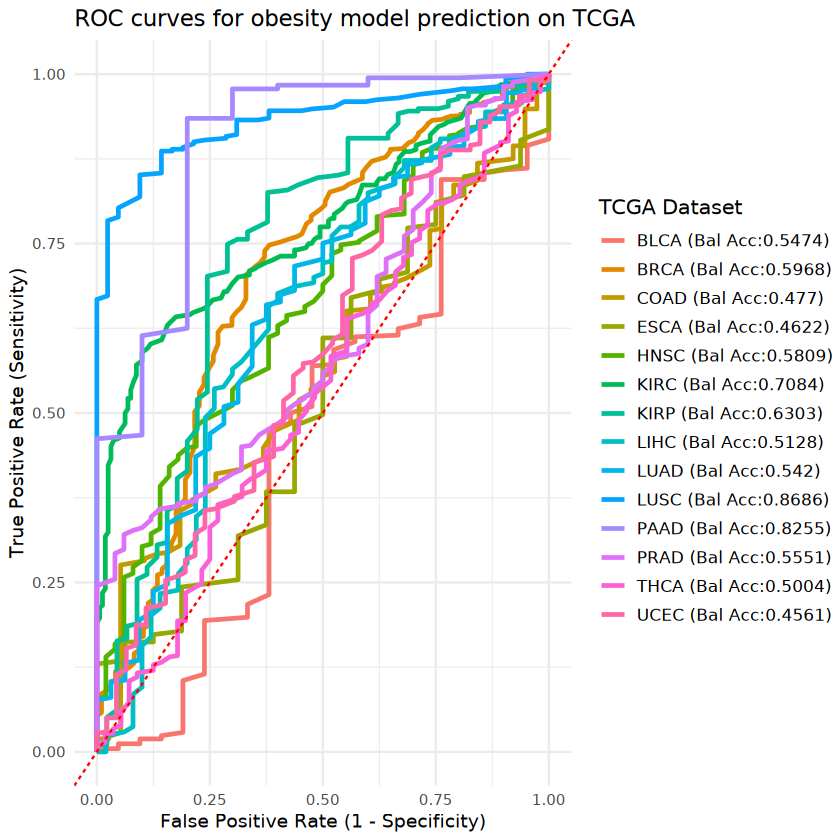

In [188]:
# Add accuracy values to the Dataset column
roc_data$Dataset2 <- as.factor(roc_data$Dataset)
levels(roc_data$Dataset2)=c(paste0('BLCA (Bal Acc:',round(BLCA_balanced,4),')'),
paste0('BRCA (Bal Acc:',round(BRCA_balanced,4),')'),
paste0('COAD (Bal Acc:',round(COAD_balanced,4),')'),
paste0('ESCA (Bal Acc:',round(ESCA_balanced,4),')'),
paste0('HNSC (Bal Acc:',round(HNSC_balanced,4),')'),
paste0('KIRC (Bal Acc:',round(KIRC_balanced,4),')'),
paste0('KIRP (Bal Acc:',round(KIRP_balanced,4),')'),
paste0('LIHC (Bal Acc:',round(LIHC_balanced,4),')'),
paste0('LUAD (Bal Acc:',round(LUAD_balanced,4),')'),
paste0('LUSC (Bal Acc:',round(LUSC_balanced,4),')'),
paste0('PAAD (Bal Acc:',round(PAAD_balanced,4),')'),
paste0('PRAD (Bal Acc:',round(PRAD_balanced,4),')'),
paste0('THCA (Bal Acc:',round(THCA_balanced,4),')'),
paste0('UCEC (Bal Acc:',round(UCEC_balanced,4),')'))
p1 = ggplot(roc_data, aes(x = FPR, y = TPR, color = Dataset2)) +
  geom_line(size = 1) +
  geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "red") +
  labs(
    title = "ROC curves for obesity model prediction on TCGA",
    x = "False Positive Rate (1 - Specificity)",
    y = "True Positive Rate (Sensitivity)",
    color = "TCGA Dataset"
  ) +
  theme_minimal() +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 12),
    legend.text = element_text(size = 10)
  )
p1

In [5]:
library(PRROC)
library(ggplot2)

In [133]:
data_all <- data.frame(
  CancerType = c("BLCA", "HNSC", "LUAD", "THCA", "BRCA", "KIRC", "LUSC", 
                 "UCEC", "COAD", "KIRP", "PAAD", "ESCA", "LIHC", "PRAD"),
  BalancedAccuracy = c(BLCA_balanced,HNSC_balanced,LUAD_balanced,THCA_balanced,BRCA_balanced,KIRC_balanced,LUSC_balanced, 
                 UCEC_balanced,COAD_balanced,KIRP_balanced,PAAD_balanced,ESCA_balanced,LIHC_balanced,PRAD_balanced),
  Accuracy =  c(BLCA_acc,HNSC_acc,LUAD_acc,THCA_acc,BRCA_acc,KIRC_acc,LUSC_acc, 
                 UCEC_acc,COAD_acc,KIRP_acc,PAAD_acc,ESCA_acc,LIHC_acc,PRAD_acc),
  Specificity =  c(BLCA_spec,HNSC_spec,LUAD_spec,THCA_spec,BRCA_spec,KIRC_spec,LUSC_spec, 
                 UCEC_spec,COAD_spec,KIRP_spec,PAAD_spec,ESCA_spec,LIHC_spec,PRAD_spec),
  Sensitivity =  c(BLCA_sens,HNSC_sens,LUAD_sens,THCA_sens,BRCA_sens,KIRC_sens,LUSC_sens, 
                 UCEC_sens,COAD_sens,KIRP_sens,PAAD_sens,ESCA_sens,LIHC_sens,PRAD_sens),
  F1 =  c(BLCA_f1,HNSC_f1,LUAD_f1,THCA_f1,BRCA_f1,KIRC_f1,LUSC_f1, 
                 UCEC_f1,COAD_f1,KIRP_f1,PAAD_f1,ESCA_f1,LIHC_f1,PRAD_f1),
  Precision = c(BLCA_precision,HNSC_precision,LUAD_precision,THCA_precision,BRCA_precision,KIRC_precision,LUSC_precision, 
                 UCEC_precision,COAD_precision,KIRP_precision,PAAD_precision,ESCA_precision,LIHC_precision,PRAD_precision),
  Recall = c(BLCA_recall,HNSC_recall,LUAD_recall,THCA_recall,BRCA_recall,KIRC_recall,LUSC_recall, 
                 UCEC_recall,COAD_recall,KIRP_recall,PAAD_recall,ESCA_recall,LIHC_recall,PRAD_recall)
)

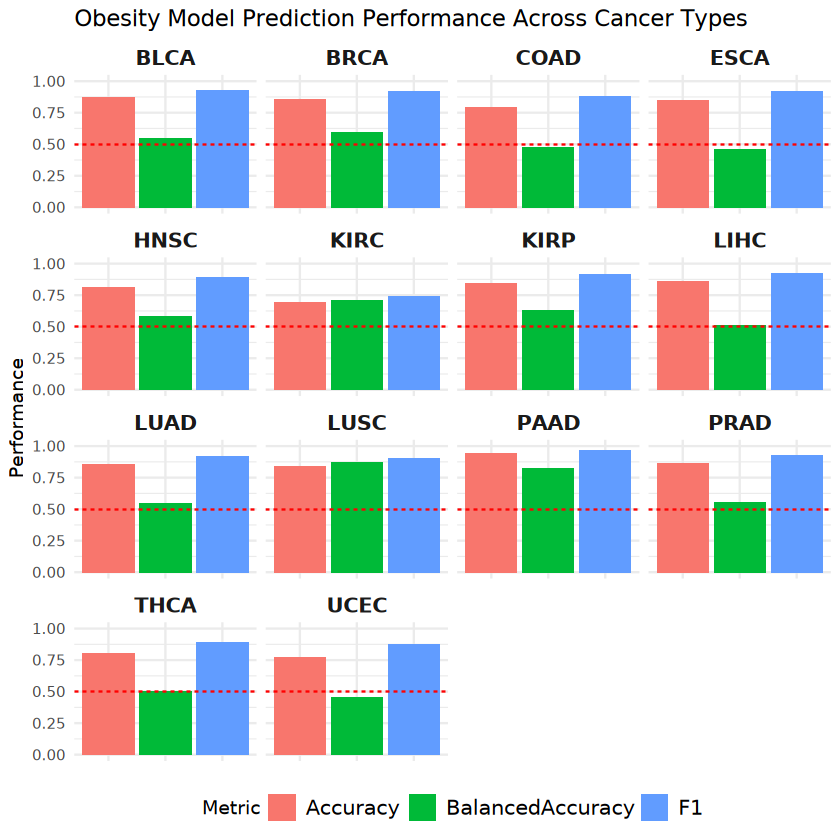

In [8]:
library(tidyr)
data_long <- data_all %>%
  pivot_longer(cols = c(Accuracy, Specificity, Sensitivity, F1, Precision, Recall,BalancedAccuracy),
               names_to = "Metric",
               values_to = "Value")
data_long <- data_all %>%
  pivot_longer(cols = c(Accuracy, F1,BalancedAccuracy),
               names_to = "Metric",
               values_to = "Value")

p2 = ggplot(data_long, aes(x = Metric, y = Value, fill = Metric)) +
  geom_bar(stat = "identity", position = "dodge") +
    geom_hline(yintercept = 0.5, linetype = "dashed", color = "red") +  
  facet_wrap(~ CancerType, ncol = 4) +
  labs(
    title = "Obesity Model Prediction Performance Across Cancer Types",
    x = NULL,
    y = "Performance"
  ) +
  scale_y_continuous(limits = c(0, 1)) +
  theme_minimal() +
  theme(
    strip.text = element_text(size = 12, face = "bold"),
    #axis.text.x = element_text(angle = 0, hjust = 1),
    legend.position = "bottom",
        axis.text.x=element_blank(),
        axis.ticks.x=element_blank(),
      legend.text=element_text(size=12)
  )
p2

In [189]:
library(ggpubr)
png('figure_obesity_tcga_roc_metric.png',width=16,height=8,res=300,unit='in')
ggarrange(p1, p2, labels = c("A", "B"),ncol=2,widths=c(1.3,1))
dev.off()

png 
  2